# Brian MF Single-Cell + Network Parity Demo

This notebook demonstrates legacy-style outputs using the new `tvbtoolkit.brian_mf` module.

What is shown:

1. Single-cell AdEx trace (legacy style): membrane voltage with spike markers.
2. Single-cell split-leak (`gK/gNa`) trace (legacy modified style).
3. Network raster + mean firing-rate plot (legacy style).
4. Network PSD plot with `fmax` marker (legacy style).

All outputs are saved to a relative directory:
`./results/figs/brian_mf_parity/`.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from tvbtoolkit.brian_mf import (
    run_single_cell_adex,
    run_adex_network_simulation,
)
from tvbtoolkit.brian_mf.adex import (
    calculate_psd_fmax,
    plot_psd,
    plot_raster_mean_fr,
)

FIG_DIR = Path('./results/figs/brian_mf_parity')
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR


PosixPath('results/figs/brian_mf_parity')

## 1) Single-cell parity (legacy `single_cell_sim.py` style)

Legacy visual style: line trace of membrane potential (`vm`) and vertical spike markers.


PosixPath('results/figs/brian_mf_parity/single_cell_legacy_style.pdf')

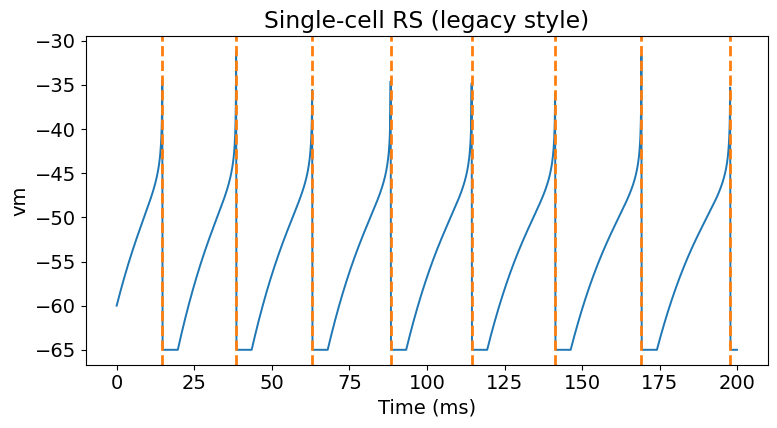

In [44]:
single = run_single_cell_adex(
    cell='RS',
    iext_na=0.315,
    time_ms=200.0,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(single.time_ms, single.voltage_mv, lw=1.4)
for t in single.spike_times_ms:
    ax.axvline(float(t), ls='--', c='C1', lw=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('vm')
ax.set_title('Single-cell RS (legacy style)')
fig.tight_layout()

out = FIG_DIR / 'single_cell_legacy_style.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
out


## 2) Single-cell split-leak parity (legacy `single_cell_sim_modified.py` style)

This reproduces the modified leak model using `gK/gNa` conversion.


PosixPath('results/figs/brian_mf_parity/single_cell_split_leak_legacy_style.pdf')

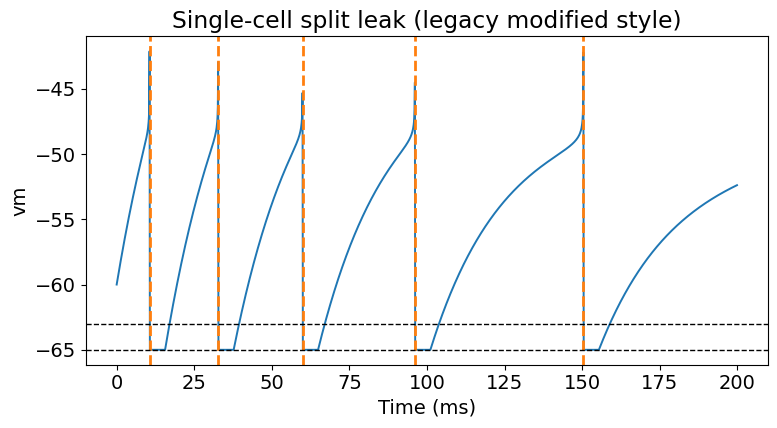

In [45]:
single_split = run_single_cell_adex(
    cell='FS',
    iext_na=0.315,
    time_ms=200.0,
    split_leak=True,
    psych=True,
    parameter_overrides={'use':True, 'b':50}
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(single_split.time_ms, single_split.voltage_mv, lw=1.4)
for t in single_split.spike_times_ms:
    ax.axvline(float(t), ls='--', c='C1', lw=2)
ax.axhline(-65.0, ls='--', c='k', lw=1)
ax.axhline(-63.0, ls='--', c='k', lw=1)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('vm')
ax.set_title('Single-cell split leak (legacy modified style)')
fig.tight_layout()

out = FIG_DIR / 'single_cell_split_leak_legacy_style.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
out


## 3) Network parity (legacy raster + mean FR style)

This section now uses legacy-scale network settings (`Ntot=10000`) and legacy drive values from `brian_MF/adex_simulation_network.py` and `brian_MF/adex_gK_gNa.py`.

If you need a quick smoke test only, reduce `Ntot` temporarily, but expect sparser/possibly silent dynamics compared with legacy outputs.


WARNING    /Users/borjan/CNRS/projects/TVBToolkit/src/tvbtoolkit/brian_mf/adex/brian_utils.py:174: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
 [py.warnings]


2026-02-20 22:57:04,038 - WARNING - py.warnings - /Users/borjan/CNRS/projects/TVBToolkit/src/tvbtoolkit/brian_mf/adex/brian_utils.py:174: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



PosixPath('results/figs/brian_mf_parity/network_raster_meanfr_legacy_style.pdf')

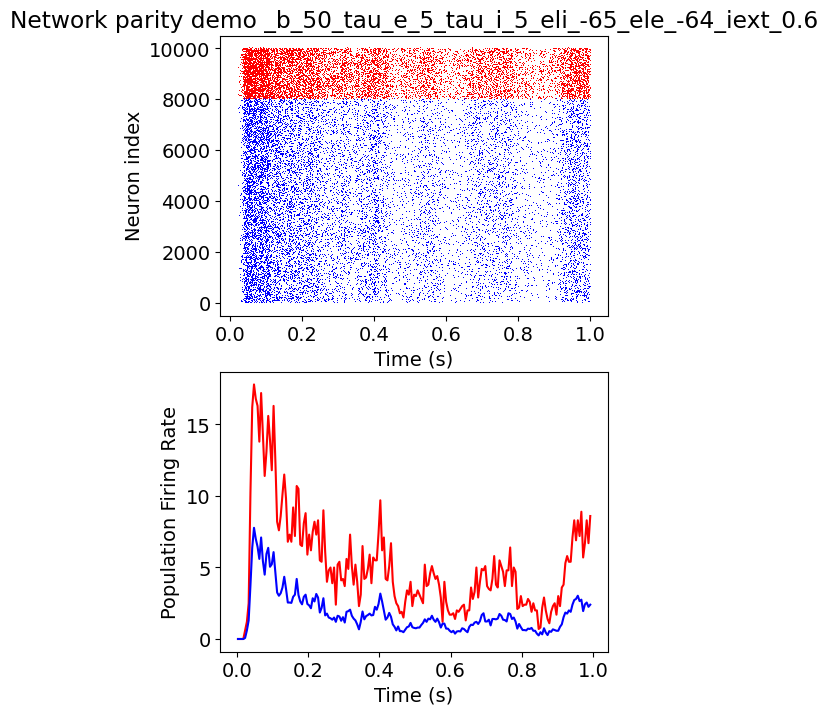

In [25]:
net = run_adex_network_simulation(
    cells='FS-RS',
    seed_value=0,
    time_ms=1000.0,
    iext_hz=0.6,
    input_hz=0.0,
    parameter_overrides={'use': True, 'Ntot': 10000, 'p_con': 0.05, 'b_e': 50},
)

# Use the legacy plotting helper directly
plot_raster_mean_fr(
    ras_inh=net.raster_inh,
    ras_exc=net.raster_exc,
    time_binned_ms=net.time_ms,
    pop_rate_inh=net.rate_inh_hz,
    pop_rate_exc=net.rate_exc_hz,
    adaptation=net.adaptation,
    input_binned=net.input_binned,
    title=f'Network parity demo {net.sim_name}',
    figsize=(5, 8),
    save=1,
    save_path=str(FIG_DIR),
    save_name='network_raster_meanfr_legacy_style.pdf',
)

FIG_DIR / 'network_raster_meanfr_legacy_style.pdf'


## 4) Network PSD parity (legacy style)

Computes FFT-based PSD and plots excitatory/inhibitory curves with `fmax`.


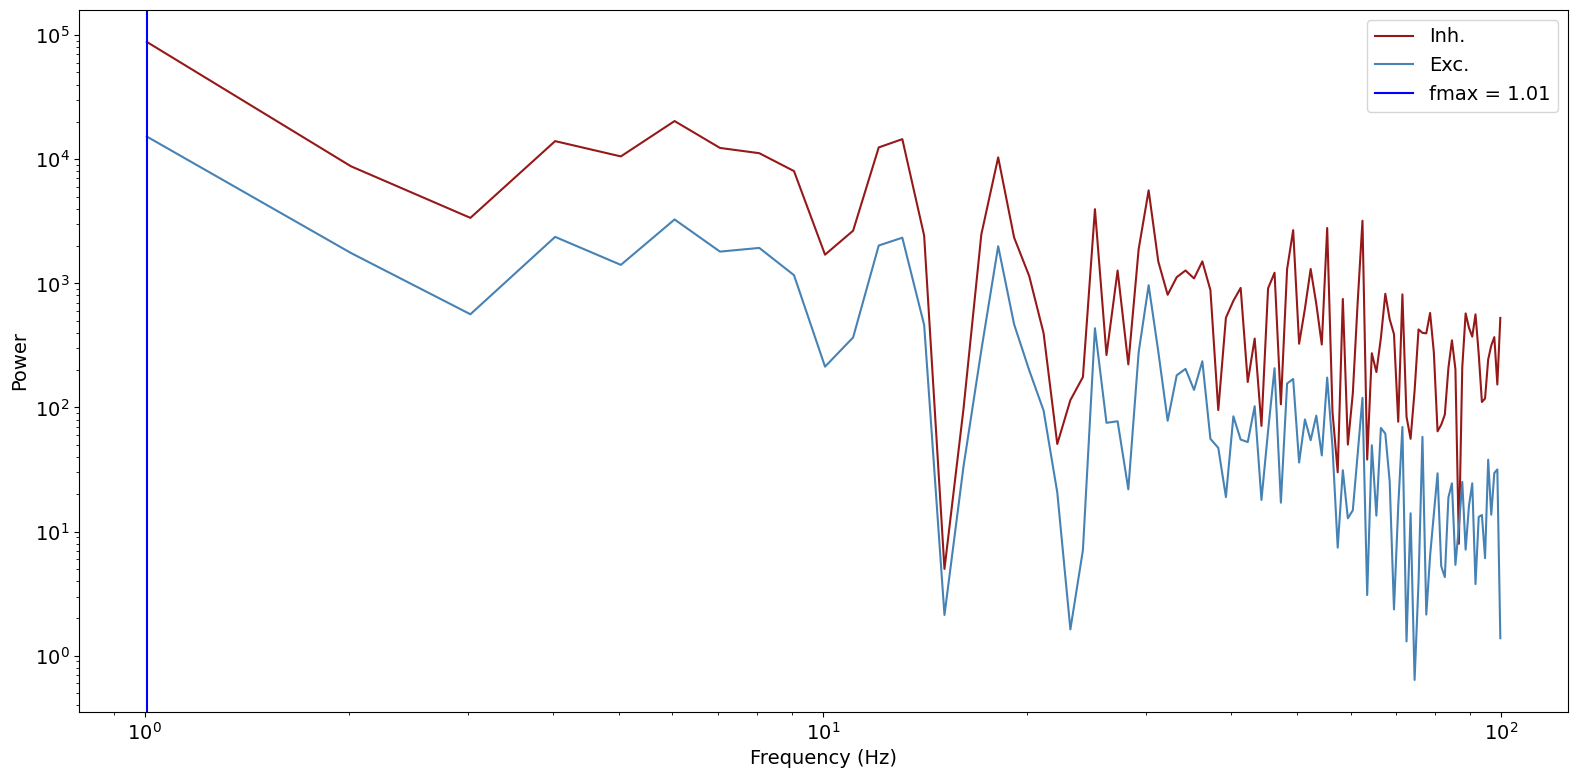

(PosixPath('results/figs/brian_mf_parity/network_psd_legacy_style.pdf'),
 1.0076074361428786)

<Figure size 640x480 with 0 Axes>

In [8]:
frq_max, frq_good, pwr_exc, pwr_inh = calculate_psd_fmax(
    net.rate_exc_hz,
    net.rate_inh_hz,
    net.time_ms,
)

plot_psd(frq_max, frq_good, pwr_exc, pwr_inh)

# Save a static copy from current figure
fig = plt.gcf()
out = FIG_DIR / 'network_psd_legacy_style.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
out, frq_max


## 5) Network split-leak parity (`adex_gK_gNa.py` style)

This uses the split leak-conductance formulation (`gK`, `gNa`) with optional psych leak shift.


WARNING    /Users/borjan/CNRS/projects/TVBToolkit/src/tvbtoolkit/brian_mf/adex/brian_utils.py:174: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
 [py.warnings]


2026-02-20 23:10:42,904 - WARNING - py.warnings - /Users/borjan/CNRS/projects/TVBToolkit/src/tvbtoolkit/brian_mf/adex/brian_utils.py:174: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



PosixPath('results/figs/brian_mf_parity/network_split_leak_raster_meanfr_legacy_style.pdf')

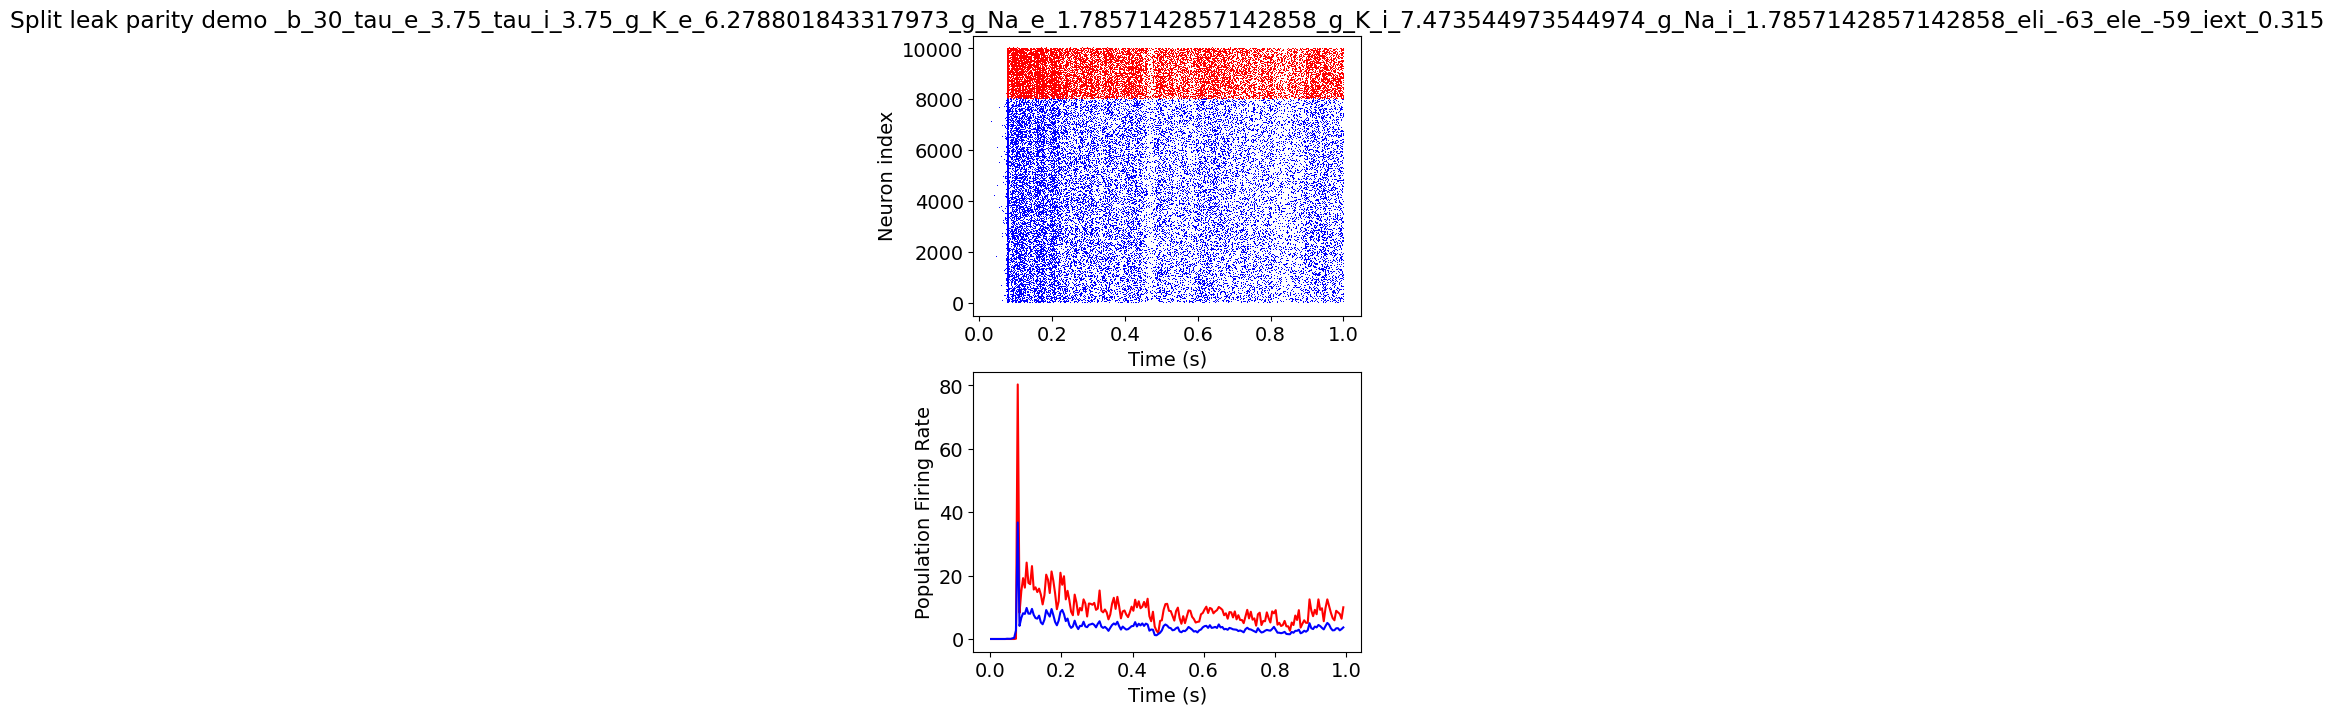

In [41]:
net_split = run_adex_network_simulation(
    cells='FS-RS_10',
    seed_value=0,
    time_ms=1000.0,
    iext_hz=0.315,
    input_hz=0.0,
    split_leak=True,
    psych=True,
    e_l_e_start_mv=-65,
    e_l_i_start_mv=-65,
    e_l_e_end_mv=-59,
    e_l_i_end_mv=-63,
    parameter_overrides={'use': True, 'Ntot': 10000, 'p_con': 0.05, 'b_e':30, 'tau_i':3.75, 'tau_e':3.75},
)

plot_raster_mean_fr(
    ras_inh=net_split.raster_inh,
    ras_exc=net_split.raster_exc,
    time_binned_ms=net_split.time_ms,
    pop_rate_inh=net_split.rate_inh_hz,
    pop_rate_exc=net_split.rate_exc_hz,
    adaptation=net_split.adaptation,
    input_binned=net_split.input_binned,
    title=f'Split leak parity demo {net_split.sim_name}',
    figsize=(5, 8),
    save=1,
    save_path=str(FIG_DIR),
    save_name='network_split_leak_raster_meanfr_legacy_style.pdf',
)

FIG_DIR / 'network_split_leak_raster_meanfr_legacy_style.pdf'


## Notes

- The plotting style intentionally follows the legacy scripts.
- Use `split_leak=True` in network simulations to mirror `adex_gK_gNa.py`.
- This notebook is parity-oriented; optimisation/refactoring can be layered on top later.
